# Pima Indians Diabetes AdaBoost 분류

## 개요
- AdaBoost Classifier를 활용한 당뇨병 예측
- 순차적 앙상블: 이전 오류에 집중
- GridSearchCV로 하이퍼파라미터 최적화

## AdaBoost 특징
- 잘못 분류된 샘플에 가중치 부여
- 약한 학습기(weak learner) 조합
- 과적합에 강한 편
- 순차적 학습 (Sequential Ensemble)

## 주요 단계
1. 데이터 로드 및 분리
2. AdaBoost 모델 설정
3. GridSearchCV 최적화
4. 성능 평가 및 피처 중요도

## 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

## 1. 데이터 로드

**Pima Indians Diabetes 데이터셋**
- 768개 샘플, 8개 피처
- 당뇨병 발병 여부 이진 분류

In [3]:
print("Loading Pima Indians Diabetes Dataset...")
pima = fetch_openml(name='diabetes', version=1, as_frame=True)
X = pima.data
y = pima.target.map({'tested_negative': 0, 'tested_positive': 1}).astype(int)

print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(X.columns)}")
print(f"\n클래스 분포:\n{y.value_counts()}")

Loading Pima Indians Diabetes Dataset...
데이터 크기: (768, 8)
피처 목록: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

클래스 분포:
class
0    500
1    268
Name: count, dtype: int64


**데이터 샘플 확인**

In [4]:
# 데이터 샘플
print("\n데이터 샘플:")
print(X.head())

print("\n기술 통계:")
print(X.describe())


데이터 샘플:
   preg  plas  pres  skin  insu  mass   pedi  age
0     6   148    72    35     0  33.6  0.627   50
1     1    85    66    29     0  26.6  0.351   31
2     8   183    64     0     0  23.3  0.672   32
3     1    89    66    23    94  28.1  0.167   21
4     0   137    40    35   168  43.1  2.288   33

기술 통계:
             preg        plas        pres        skin        insu        mass  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
std      3.369578   31.972618   19.355807   15.952218  115.244002    7.884160   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.000000   62.000000    0.000000    0.000000   27.300000   
50%      3.000000  117.000000   72.000000   23.000000   30.500000   32.000000   
75%      6.000000  140.250000   80.000000   32.000000  127.250000   36.600000   
max     17.000000  199.000000  122.

**학습/테스트 데이터 분리**

In [5]:
# 데이터 분리 (stratify로 클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain 클래스 분포:\n{y_train.value_counts()}")

Train: (614, 8), Test: (154, 8)

Train 클래스 분포:
class
0    400
1    214
Name: count, dtype: int64


## 2. AdaBoost Classifier

**AdaBoost 작동 원리**
1. 첫 번째 약한 학습기 학습
2. 잘못 분류된 샘플에 가중치 증가
3. 다음 학습기는 높은 가중치 샘플에 집중
4. 반복하여 최종 강한 분류기 생성

**특징**
- 순차적 학습: 이전 오류 보완
- 약한 학습기: 보통 max_depth=1 (stump)
- 가중치 조정: 오분류 샘플 강조
- 과적합 저항: learning_rate로 조절

**하이퍼파라미터**
- n_estimators: 생성할 약한 학습기 개수
- learning_rate: 각 학습기의 기여도
- estimator: 기본 약한 학습기 (DecisionTree)

**모델 설정**

In [6]:
# AdaBoost Classifier
# estimator: max_depth=1인 Decision Tree (Decision Stump)
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    random_state=42
)

print("AdaBoost Classifier 생성")
print(f"Base Estimator: DecisionTreeClassifier(max_depth=1)")

AdaBoost Classifier 생성
Base Estimator: DecisionTreeClassifier(max_depth=1)


## 3. GridSearchCV 하이퍼파라미터 탐색

**파라미터 그리드**
- n_estimators: [50, 100, 200]
- learning_rate: [0.01, 0.1, 1.0, 1.5]

**learning_rate 의미**
- 낮은 값 (0.01): 느린 학습, 안정적
- 높은 값 (1.5): 빠른 학습, 불안정 가능

In [7]:
# 하이퍼파라미터 그리드
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0, 1.5]
}

print("파라미터 그리드:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\n총 조합 수: {total_combinations}개")

파라미터 그리드:
  n_estimators: [50, 100, 200]
  learning_rate: [0.01, 0.1, 1.0, 1.5]

총 조합 수: 12개


In [8]:
# GridSearchCV
print("\nTuning AdaBoost Classifier...")
print("(교차검증 수행 중...)\n")

grid_clf = GridSearchCV(
    ada_clf,
    param_grid,
    cv=StratifiedKFold(5),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_clf.fit(X_train, y_train)
print("\nGridSearchCV 완료!")


Tuning AdaBoost Classifier...
(교차검증 수행 중...)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

GridSearchCV 완료!


## 4. 최적화 결과 분석

**최적 모델 정보**

In [9]:
# 최적 모델 추출
best_clf = grid_clf.best_estimator_

print("[최적화 결과]")
print(f"Best Accuracy (Train CV): {grid_clf.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in grid_clf.best_params_.items():
    print(f"  {param}: {value}")

[최적화 결과]
Best Accuracy (Train CV): 0.7671

Best Parameters:
  learning_rate: 0.1
  n_estimators: 200


**GridSearchCV 상위 결과**

In [10]:
# 상위 5개 결과
cv_results = pd.DataFrame(grid_clf.cv_results_)
top_results = cv_results.nlargest(5, 'mean_test_score')[[
    'param_n_estimators',
    'param_learning_rate',
    'mean_test_score',
    'std_test_score'
]]

print("\n상위 5개 파라미터 조합:")
print(top_results.to_string(index=False))


상위 5개 파라미터 조합:
 param_n_estimators  param_learning_rate  mean_test_score  std_test_score
                200                  0.1         0.767133        0.013666
                100                  1.0         0.767053        0.022128
                 50                  1.0         0.765480        0.021348
                200                  1.0         0.765467        0.012026
                100                  0.1         0.763868        0.011001


## 5. 테스트 데이터 평가

**예측 및 성능 평가**

In [11]:
# 테스트 데이터 예측
y_pred = best_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.7597

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.77      0.89      0.83       100
           1       0.72      0.52      0.60        54

    accuracy                           0.76       154
   macro avg       0.75      0.70      0.72       154
weighted avg       0.75      0.76      0.75       154



**Confusion Matrix**

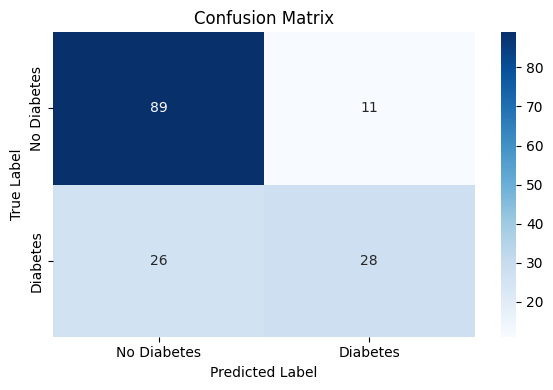

In [19]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 6. 피처 중요도 분석

**AdaBoost 피처 중요도**
- 각 약한 학습기의 중요도를 가중 합산
- 높은 값: 분류에 중요한 피처
- 낮은 값: 영향력 낮은 피처

In [13]:
# 피처 중요도 추출
importances = best_clf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# 중요도 정렬
importance_df = pd.DataFrame({
    'Feature': feature_names[indices],
    'Importance': importances[indices]
})

print("\n피처 중요도 순위:")
print(importance_df.to_string(index=False))


피처 중요도 순위:
Feature  Importance
   mass    0.406911
   plas    0.399886
    age    0.080327
   pedi    0.061607
   preg    0.051269
   insu    0.000000
   pres    0.000000
   skin    0.000000


**피처 중요도 시각화**

/tmp/ipython-input-2435146505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


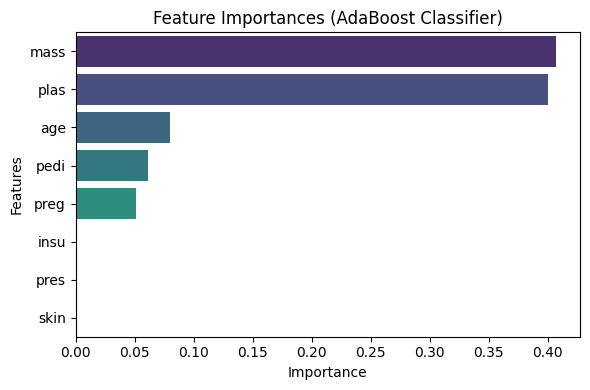

In [18]:
# 피처 중요도 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title("Feature Importances (AdaBoost Classifier)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## 7. AdaBoost vs Random Forest 비교

**동일 데이터로 Random Forest와 비교**

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# 비교
print("\n앙상블 모델 비교:")
print(f"AdaBoost: Accuracy = {test_accuracy:.4f}")
print(f"Random Forest: Accuracy = {accuracy_rf:.4f}")
print(f"\n차이: {test_accuracy - accuracy_rf:+.4f}")


앙상블 모델 비교:
AdaBoost: Accuracy = 0.7597
Random Forest: Accuracy = 0.7597

차이: +0.0000


## 8. Learning Rate 영향 분석

**다양한 learning_rate에 따른 성능 변화**

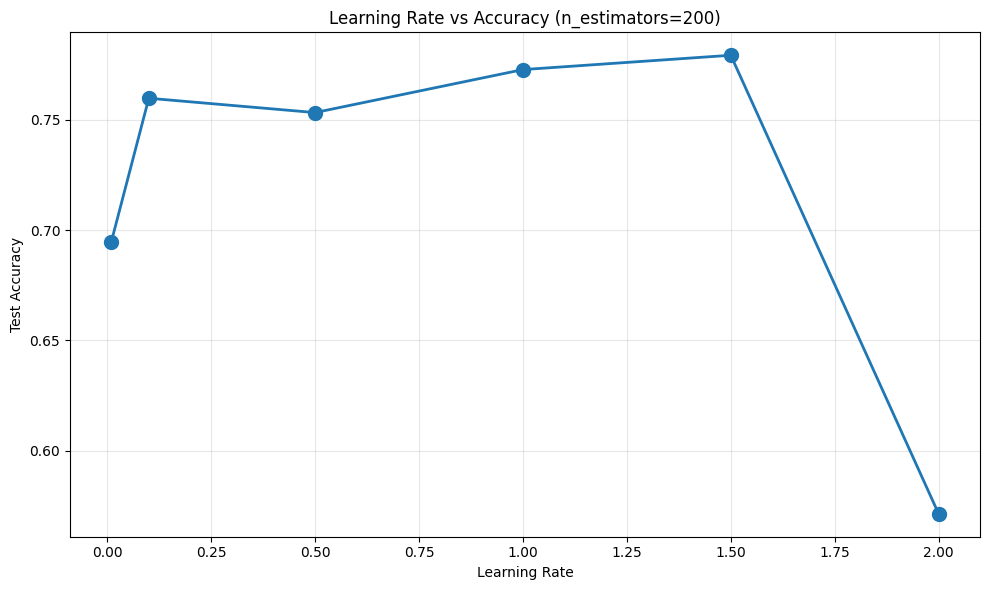


Learning Rate별 성능:
  LR=0.01: 0.6948
  LR=0.10: 0.7597
  LR=0.50: 0.7532
  LR=1.00: 0.7727
  LR=1.50: 0.7792
  LR=2.00: 0.5714


In [20]:
# learning_rate별 성능
learning_rates = [0.01, 0.1, 0.5, 1.0, 1.5, 2.0]
scores = []

best_n_estimators = grid_clf.best_params_['n_estimators']

for lr in learning_rates:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=best_n_estimators,
        learning_rate=lr,
        random_state=42
    )
    ada.fit(X_train, y_train)
    score = ada.score(X_test, y_test)
    scores.append(score)

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(learning_rates, scores, marker='o', linewidth=2, markersize=10)
plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy')
plt.title(f'Learning Rate vs Accuracy (n_estimators={best_n_estimators})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nLearning Rate별 성능:")
for lr, score in zip(learning_rates, scores):
    print(f"  LR={lr:.2f}: {score:.4f}")

## 9. Estimators 개수에 따른 성능

**약한 학습기 개수 증가에 따른 효과**

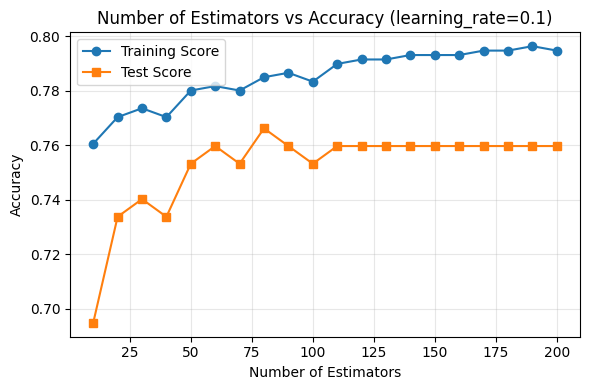

In [22]:
# n_estimators별 성능
n_estimators_range = range(10, 210, 10)
train_scores = []
test_scores = []

best_lr = grid_clf.best_params_['learning_rate']

for n_est in n_estimators_range:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n_est,
        learning_rate=best_lr,
        random_state=42
    )
    ada.fit(X_train, y_train)
    train_scores.append(ada.score(X_train, y_train))
    test_scores.append(ada.score(X_test, y_test))

# 시각화
plt.figure(figsize=(6, 4))
plt.plot(n_estimators_range, train_scores, label='Training Score', marker='o')
plt.plot(n_estimators_range, test_scores, label='Test Score', marker='s')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title(f'Number of Estimators vs Accuracy (learning_rate={best_lr})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()